In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append("/content/drive/MyDrive/stocks/duet_regression")

from pipeline.config import DUETConfig
from pipeline import train, evaluate, predict
from pipeline.prepare_and_check import FinancialTimeSeriesPreparer
from pipeline.wf_slicer import GlobalNormConfig, SplitConfig, WalkForwardWindowSlicerVec, WindowConfig
from duet.model import DUETModel
from torch.utils.data import DataLoader, TensorDataset
import torch
import joblib
import random
import numpy as np
import os


In [ ]:
PATH = "/content/drive/MyDrive/stocks/Data/DOGEUSDT/preprocessed/DOGEUSDT_1m_2024-01-01_to_2025-05-23_agg_15min_bb_20_2_shifted.joblib"
df = joblib.load(PATH)

In [ ]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['dtrended_close'] = df['Close'] - df['SMA_20']
df['std_20'] = df['Close'].rolling(window=20).std()
df['returns'] = df['Close'].pct_change()

joblib.dump(df, PATH)


['/content/drive/MyDrive/stocks/Data/DOGEUSDT/preprocessed/DOGEUSDT_1m_2024-01-01_to_2025-05-23_agg_15min_bb_20_2_shifted.joblib']

In [ ]:
df.columns

Index(['timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 'sma', 'upper',
       'lower', 'sigma', 'SMA_20', 'dtrended_close', 'std_20', 'returns'],
      dtype='object')

In [ ]:
# Настройки
joblib_path = "/content/drive/MyDrive/stocks/Data/DOGEUSDT/preprocessed/DOGEUSDT_1m_2024-01-01_to_2025-05-23_agg_15min_bb_20_2_shifted.joblib"
df = joblib.load(joblib_path)
device = "cuda" if torch.cuda.is_available() else "cpu"

config = DUETConfig(
    # =========================
    # Общие параметры
    # =========================
    timestamp_col = "timestamp",      # Название колонки содержащей timstamp (int)
    features = [
       'Open', 'High', 'Low', 'Close', 'SMA_20', 'dtrended_close', 'std_20', 'returns'
    ],
    forecast = [
        'std_20'
    ],            # Название колонок для предикта
    not_to_normalise = [],            # Название колонок, которые НЕ НАДО нормализовать
    scaler = 'MINMAX',                   # Тип нормализации (STD, MINMAX, QUANT)
    seq_len = 48,                     # Длина входной последовательности
    horizon = 6,                     # Длина выходного прогноза
    patch_len = 16,                   # Длина патча (TCM)
    stride = 8,                      # Шаг между патчами (TCM)
    moving_avg = 11,                  # Размер окна скользящего сглаживания

    # =========================
    # Параметры модели
    # =========================
    d_model = 128,                    # Размерность скрытого пространства в attention
    d_ff = 512,                      # Размерность feedforward слоя
    n_heads = 4,                      # Количество голов в multi-head attention
    e_layers = 3,                     # Количество слоев в encoder (CCM)
    dropout = 0.2,                    # Dropout во всех слоях attention
    fc_dropout = 0.2,                 # Dropout в выходном head слое
    activation = "relu",              # Активационная функция (relu, gelu, elu)
    num_experts = 2,                  # Число экспертов (в Router, если используется)

    # =========================
    # Режимы обработки
    # =========================
    CI = True,                 # Channel-Independent режим (если False — shared weights)
    use_router = False,          # Включить распределительный роутер
    timeenc = 0,                # Использовать time encoding (0 = без, 1 = sin/cos и т.п.)

    # =========================
    # Настройки обучения
    # =========================
    batch_size = 64,            # Размер батча
    epochs = 10,                # Количество эпох
    learning_rate = 0.0001,    # Скорость обучения
    weight_decay = 1e-6,      # L2 регуляризация
    patience = 20,               # Патенс для early stopping
    loss = "mse" ,              # Функция потерь: mse, mae, smape, mase
    metric = "mae",             # Основная метрика: mae, smape, mase

    # =========================
    # Прочее
    # =========================
    checkpoint_best = '/content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt',       # Путь для сохранения лучших по val_accuracy весов
    checkpoint_final = '/content/drive/MyDrive/stocks/duet_regression/weights/final_weights_01.pt',      # Путь для сохранения финальных весов
    seed = 22221,                  # Фиксированное зерно генератора случайных чисел
    verbose = True,            # Печать хода обучения
)

"""
Устанавливает seed для numpy, random, torch (вкл. CUDA).
Гарантирует воспроизводимость.
"""

random.seed(config.seed)
np.random.seed(config.seed)
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)


In [ ]:
df = joblib.load(joblib_path)
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'sigma_log_return_14',
       'sigma_bollinger_14', 'sigma_true_range_14', 'min_extr_distance_14',
       'max_extr_distance_14', 'efficiency_ratio_14', 'sigma_bolinger_15',
       'RSI_Close_15', 'er_15', 'sigma_bolinger_30', 'RSI_Close_30', 'er_30',
       'sigma_bolinger_60', 'RSI_Close_60', 'er_60', 'high_trend', 'low_trend',
       'high_trend_noise', 'low_trend_noise', 'signal_abs_speed',
       'signal_abs_accel', 'volume_abs_speed', 'volume_abs_accel'],
      dtype='object')

In [ ]:
# Загрузка данных
df = joblib.load(joblib_path)
preparer = FinancialTimeSeriesPreparer(
    tz="UTC",
    timestamp_col=config.timestamp_col,
    drop_warmup=True,
)
df, _ = preparer.prepare(df, ensure_ohlcv=True)

split = SplitConfig(
    n_folds=1,
    mode="expanding",
    ratios=(0.8, 0.1, 0.1),
    step_size=None,
    gap=0,
    sliding_train_size=None,
)

window = WindowConfig(
    x_window=config.seq_len,
    x_end_offset=0,
    y_window=config.horizon,
    y_end_offset=config.horizon,
    allow_left_context_for_x=False,
)

scaler_map = {"STD": "standard", "MINMAX": "minmax", "QUANT": "quantile", "NONE": "none"}
global_norm = GlobalNormConfig(scaler=scaler_map.get(config.scaler.upper(), "none"))

slicer = WalkForwardWindowSlicerVec(
    split=split,
    window=window,
    global_norm=global_norm,
    no_norm_cols=config.not_to_normalise,
    eps=1e-12,
    drop_incomplete_last_fold=True,
)

out = slicer.split_and_window(
    X=df[config.features],
    y=df[config.forecast],
)
fold0 = out["fold_0"]

x_train = fold0["train"]["X"]
y_train = fold0["train"]["y"]
x_val = fold0["val"]["X"]
y_val = fold0["val"]["y"]

# DataLoader
train_loader = DataLoader(TensorDataset(torch.tensor(x_train, dtype=torch.float32),
                                        torch.tensor(y_train, dtype=torch.float32)),
                          batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(x_val, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.float32)),
                        batch_size=config.batch_size)


Индекс уже в формате datetime
Инферированная частота: min
Пропусков в индексе не обнаружено
Окончательно удалено 19 строк содеражащих NaN


Windowing: 100%|██████████| 146536/146536 [01:37<00:00, 1495.32it/s]


In [ ]:
# Обучение
model = DUETModel(config).to(device)


if os.path.isfile(config.checkpoint_best):
    print("Загрузка сохраненных весов")
    last_dim = len(set(config.features + config.forecast)) + (config.timeenc + 1) * 5
    dummy_input = torch.tensor(np.zeros(shape = (config.batch_size, config.seq_len, last_dim )), dtype=torch.float32).to(device)
    model(dummy_input)
    model.load_state_dict(torch.load(config.checkpoint_best)) # загрузка лучших весов
else:
    print("Файл не найден")

model = train.train_model(model, config, train_loader, val_loader, device=device)

Файл не найден


[1/10] Train: 0.0837 | Val: 0.0475
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt


[2/10] Train: 0.0610 | Val: 0.0457
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt


[3/10] Train: 0.0578 | Val: 0.0450
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt


[4/10] Train: 0.0564 | Val: 0.0438
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt


...

[6/10] Train: 0.0548 | Val: 0.0437
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt


[7/10] Train: 0.0543 | Val: 0.0441


[8/10] Train: 0.0539 | Val: 0.0436
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt


[9/10] Train: 0.0536 | Val: 0.0434
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt


[10/10] Train: 0.0532 | Val: 0.0432
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_regression/weights/best_val_acc_weights_01.pt
Saving final model weights to /content/drive/MyDrive/stocks/duet_regression/weights/final_weights_01.pt


In [ ]:
y_true, y_pred = evaluate.evaluate_model(model, val_loader, device=device)
metrics = evaluate.compute_metrics(y_true, y_pred)
metrics


{'mae': 4.525082840700634e-05,
 'rmse': np.float64(8.216565950907478e-05),
 'smape': np.float32(11.892958)}

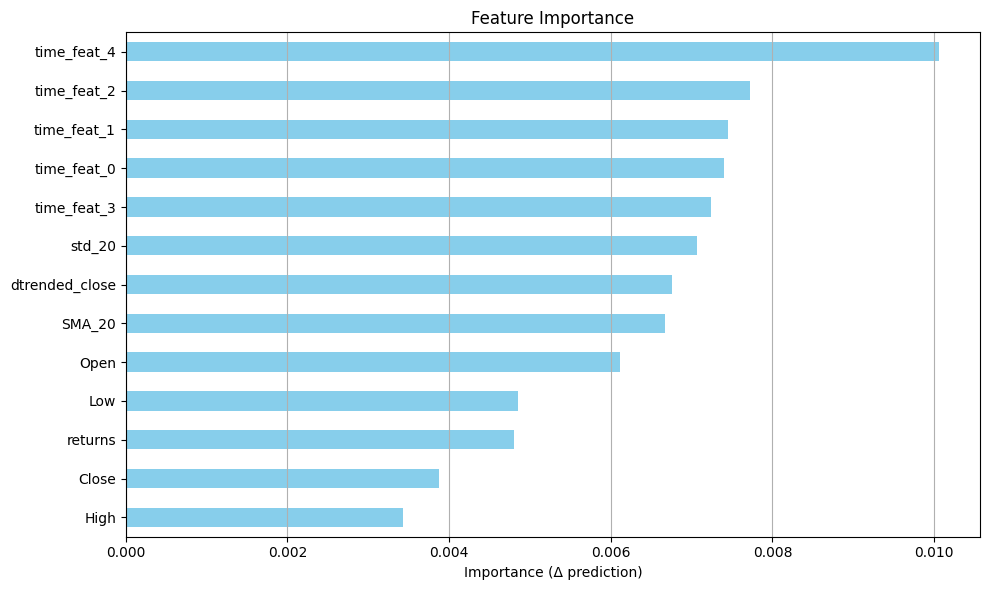

In [ ]:
from pipeline.evaluate import compute_feature_importance

sample = df[-5000:]
compute_feature_importance(model, sample, config, device=device)


In [ ]:
# Загрузка весов
model = DUETModel(config).to(device)
last_dim = len(set(config.features + config.forecast)) + (config.timeenc + 1) * 5
dummy_input = torch.tensor(np.zeros(shape = (config.batch_size, config.seq_len, last_dim )), dtype=torch.float32).to(device)
model(dummy_input)
model.load_state_dict(torch.load(config.checkpoint_best)) # загрузка лучших весов
# model.load_state_dict(torch.load(config.checkpoint_final)) # загрузка финальных весов
model.eval()

DUETModel(
  (tcm): TCM(
    (decomp): SeriesDecomposition(
      (avg_pool): AvgPool1d(kernel_size=(11,), stride=(1,), padding=(5,))
    )
    (extractor): LinearPatternExtractor(
      (projection): ModuleList(
        (0): Linear(in_features=32, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (ccm): CCM(
    (enc_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (attn): MultiHeadSelfAttention(
          (qkv_proj): Linear(in_features=128, out_features=384, bias=True)
          (out_proj): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (dropout1): Dropout(p=0.2, inplace=False)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (activation): ReLU()
        (ffn): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Line

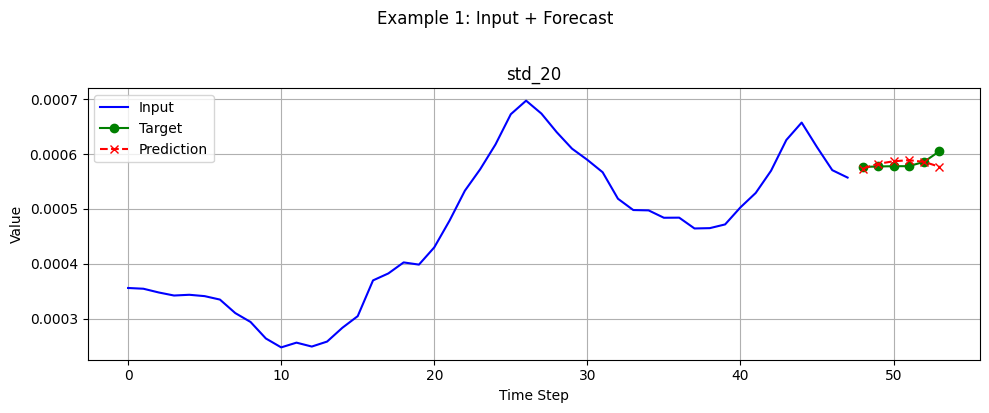

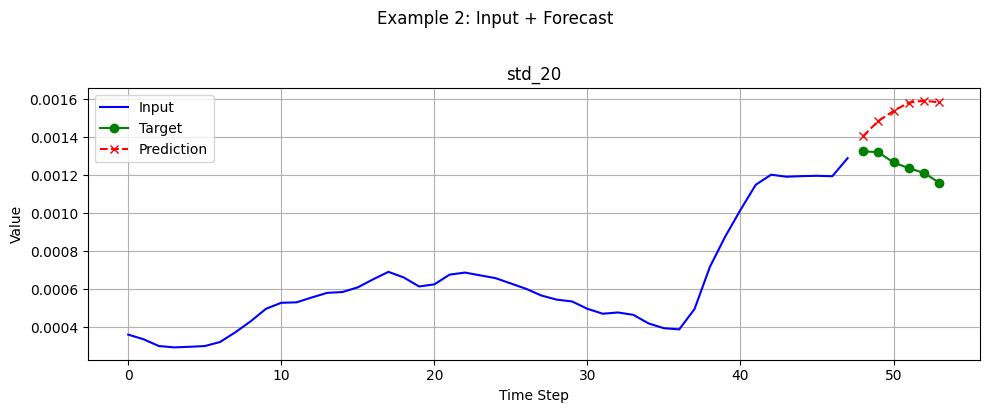

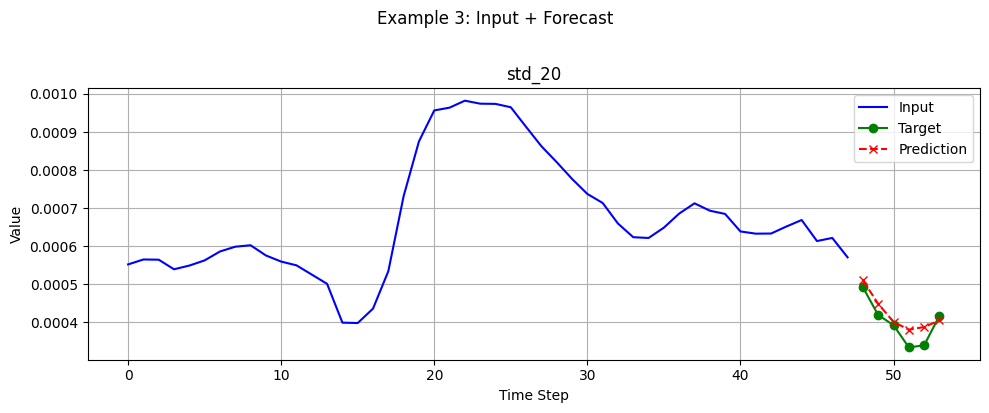

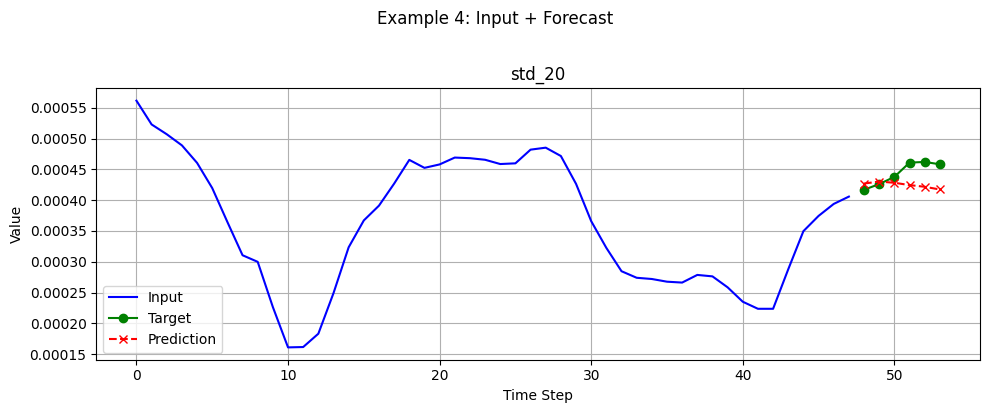

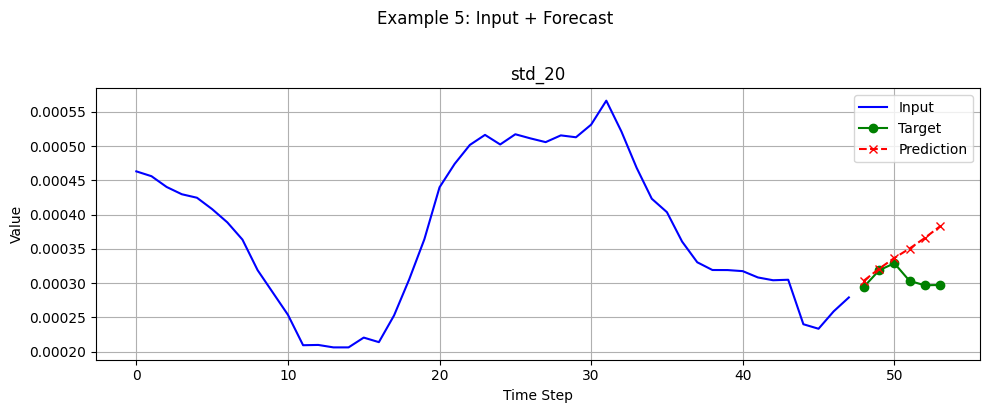

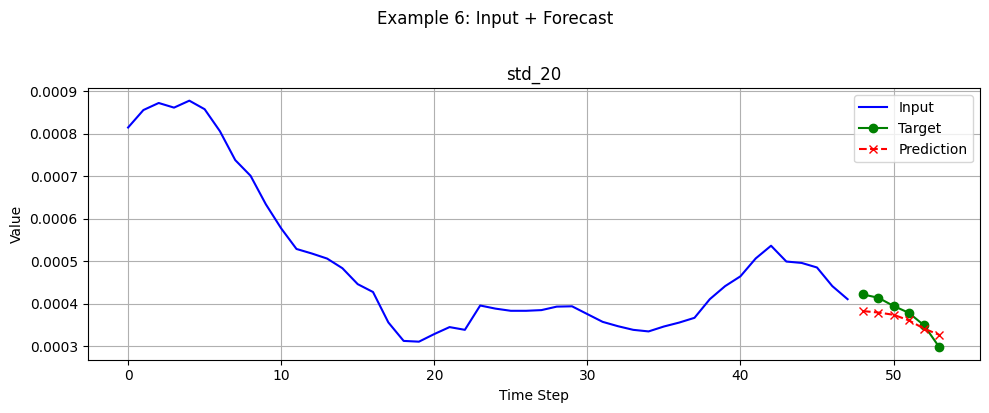

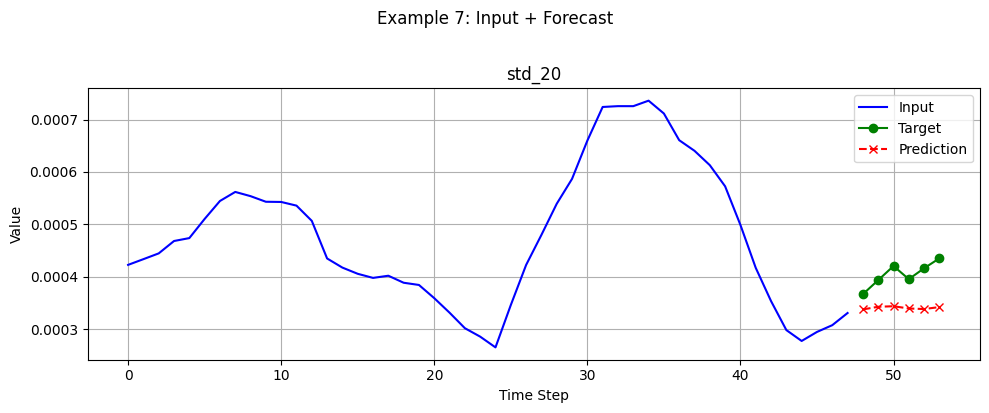

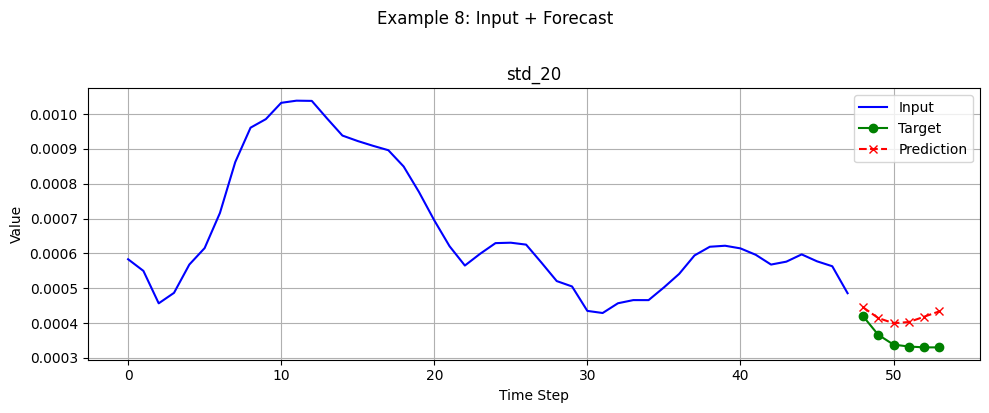

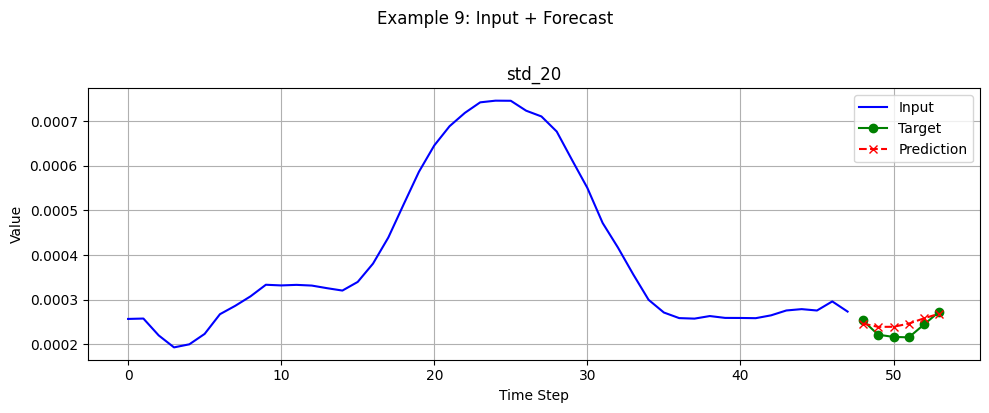

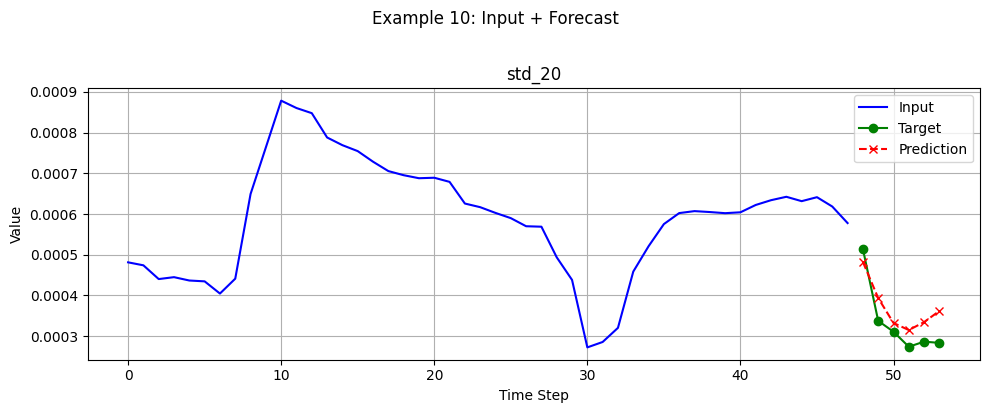

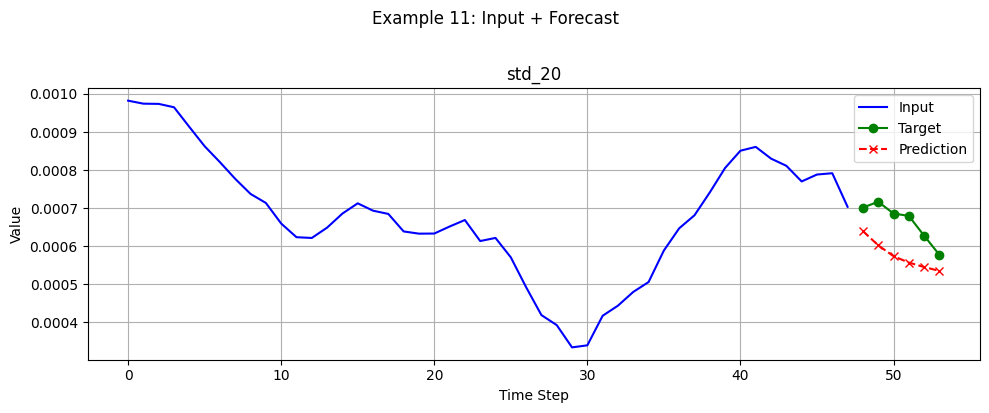

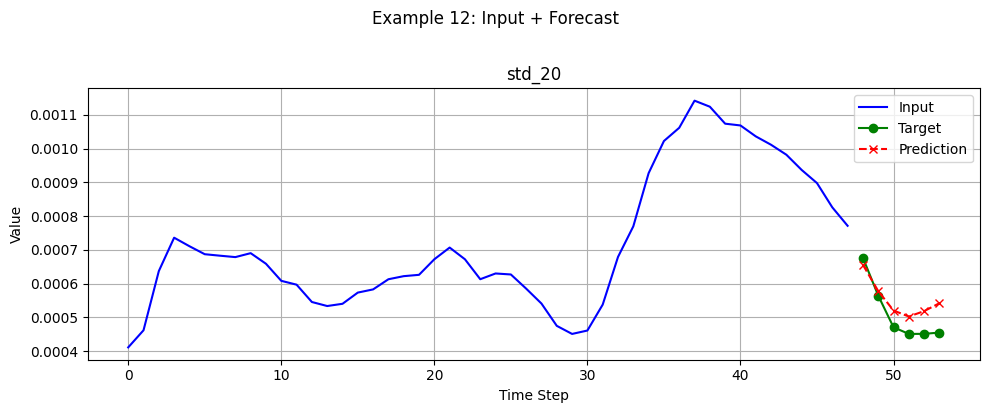

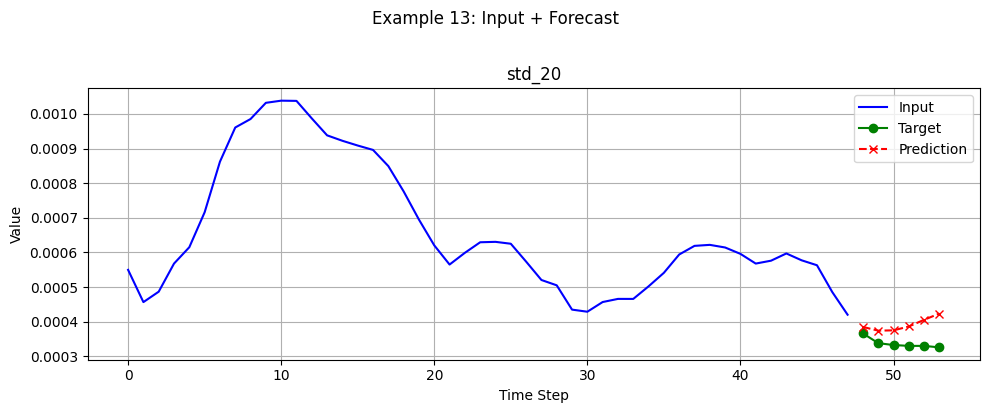

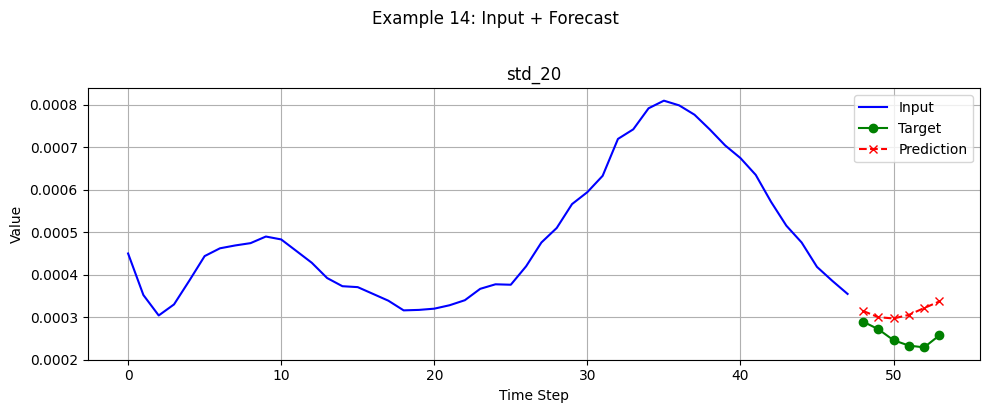

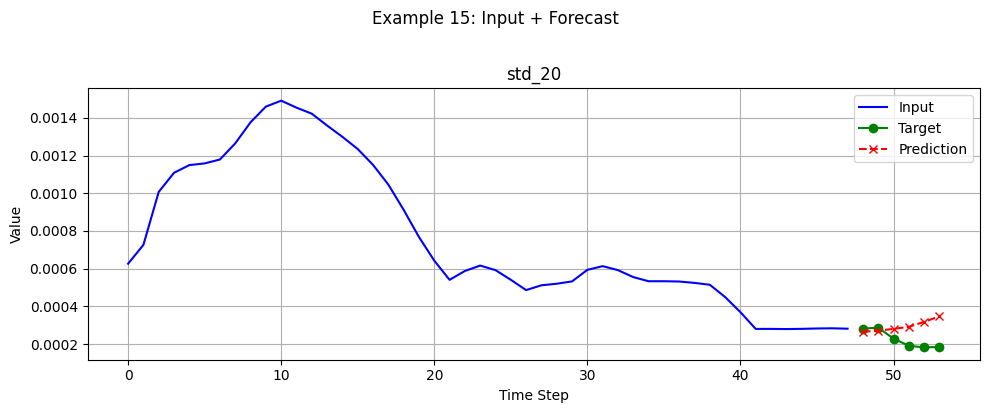

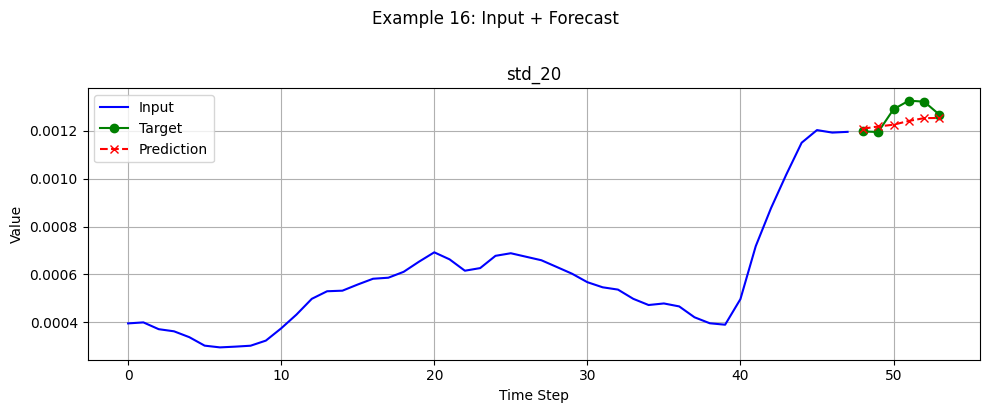

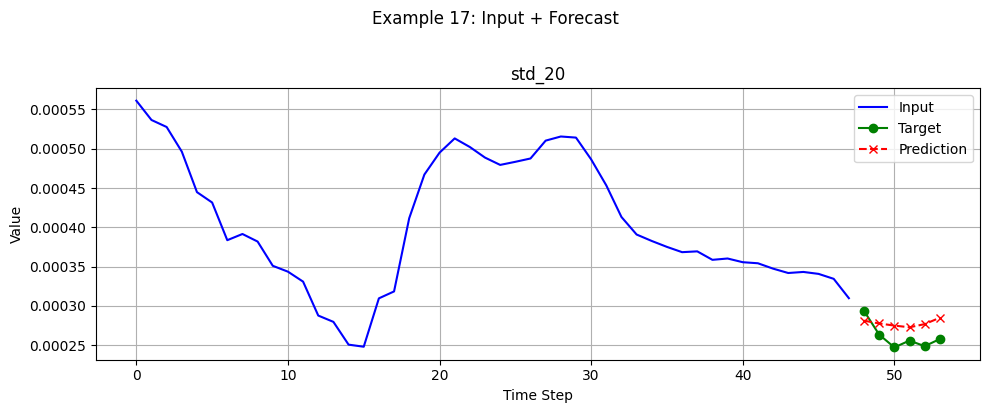

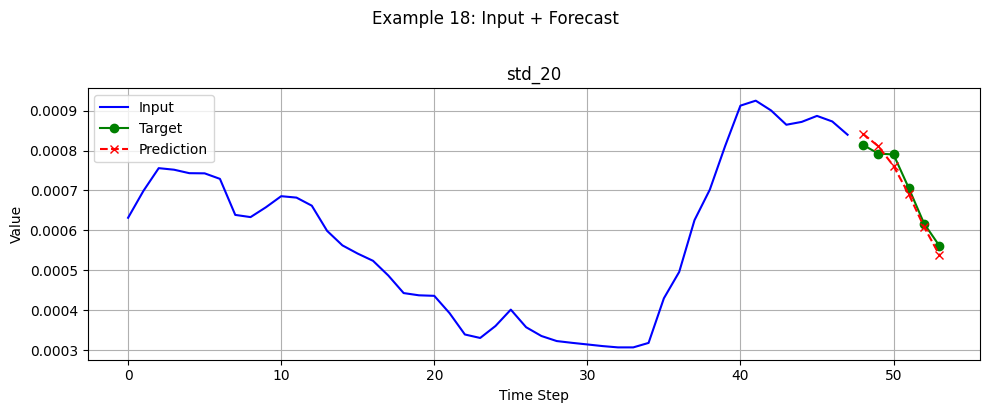

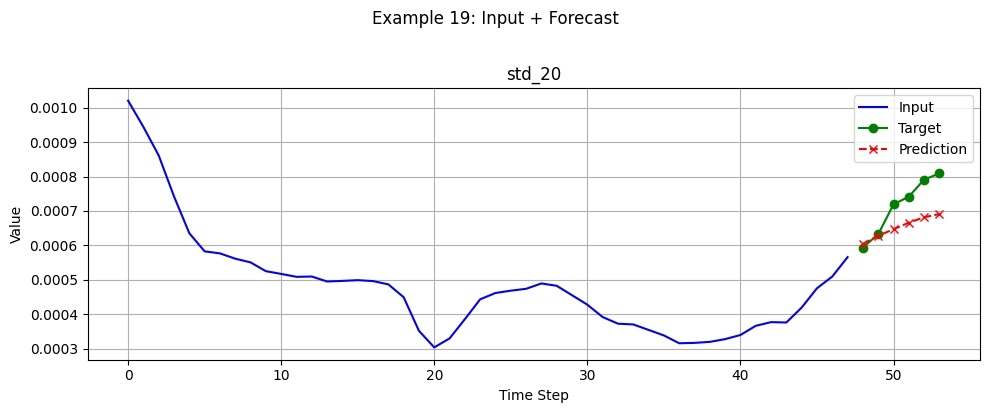

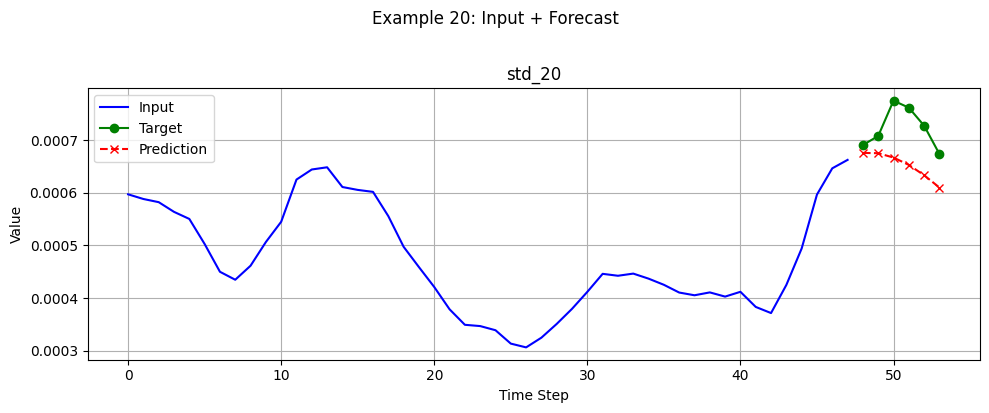

In [ ]:
from pipeline.predict import plot_random_windows

plot_random_windows(model, sample, config, n=20, device=device)